In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:

heart_disease = fetch_ucirepo(id=45)

# data
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [3]:
df=heart_disease.data.original
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [4]:
# Exercício 1 : For each categorical variable, report the relative frequencies of categories.

categoricas = ["sex","cp","fbs","restecg","exang","slope","thal"]

for i in categoricas:
    print(df[i].value_counts(normalize=True))


sex
1    0.679868
0    0.320132
Name: proportion, dtype: float64
cp
4    0.475248
3    0.283828
2    0.165017
1    0.075908
Name: proportion, dtype: float64
fbs
0    0.851485
1    0.148515
Name: proportion, dtype: float64
restecg
0    0.498350
2    0.488449
1    0.013201
Name: proportion, dtype: float64
exang
0    0.673267
1    0.326733
Name: proportion, dtype: float64
slope
1    0.468647
2    0.462046
3    0.069307
Name: proportion, dtype: float64
thal
3.0    0.551495
7.0    0.388704
6.0    0.059801
Name: proportion, dtype: float64


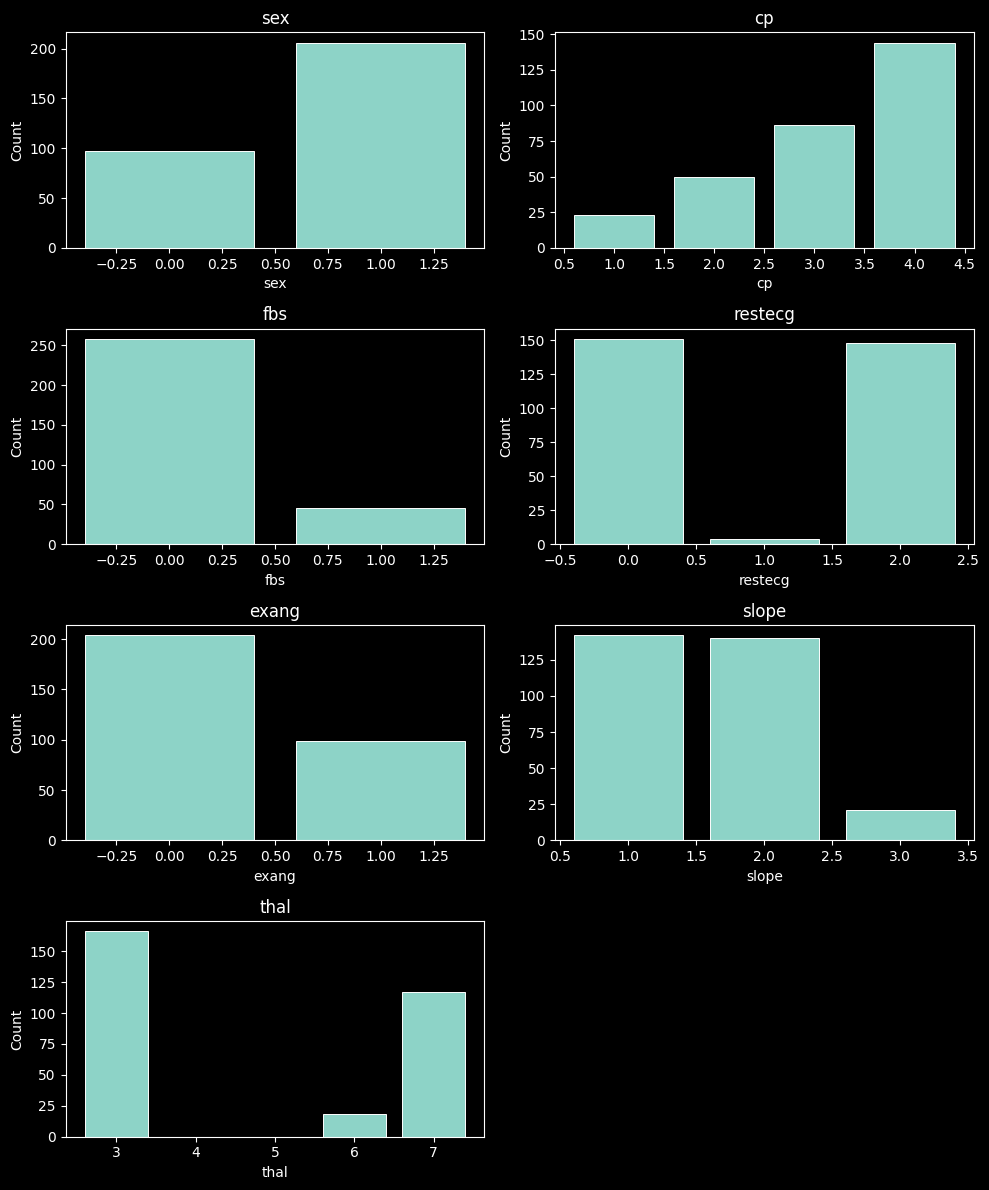

In [5]:
# Exercício 2 : Create appropriate visualizations to show the distribution of all categorical variables.
import numpy as np
import matplotlib.pyplot as plt

categoricas = ["sex","cp","fbs","restecg","exang","slope","thal"]

fig, axs = plt.subplots(4, 2, figsize=(10,12))

for i, cat in enumerate(categoricas):

    ax = axs.flat[i]  #Transforma a grelha((array 2D) de eixos do Matplotlib) numa lista e depois escolhe um eixo especifico para desenhar o grafico

    counts = df[cat].value_counts().sort_index()

    ax.bar(counts.index, counts.values,
           edgecolor="white", linewidth=0.7)

    ax.set_title(cat)
    ax.set_xlabel(cat)
    ax.set_ylabel("Count")

# remover gráfico extra (8º)
fig.delaxes(axs.flat[7])
plt.tight_layout()
plt.show()

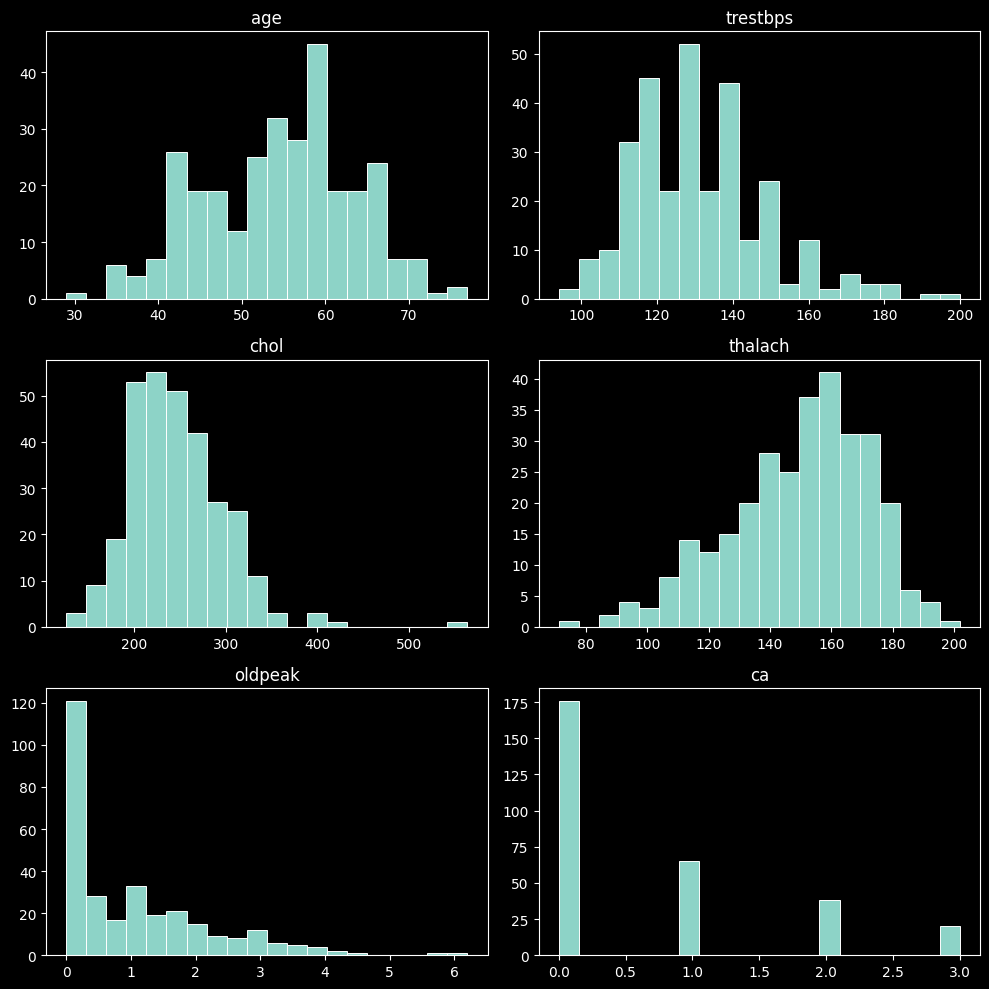

In [6]:
# Exercício 3 :Create appropriate visualizations to show the distribution of all numeric variables.

numericas = ["age","trestbps","chol","thalach","oldpeak","ca"]

# limpar dados primeiro

df = df.replace("?", np.nan) # substitui valores como simbulos "?" por NaN

df = df.apply(pd.to_numeric, errors="coerce")   #substitui todos os valores por numericos apenas ou NaN no caso de letras

fig, axs = plt.subplots(3,2, figsize=(10,10))   #apresenta 6 gráficos de 3 linhas e 2 colunas cada

for i, num in enumerate(numericas):

    ax = axs.flat[i]  #Transforma a grelha numa lista e depois escolhe um eixo especifico para desenhar o grafico

    ax.hist(df[num].dropna(), bins=20, edgecolor="white", linewidth=0.7)

    ax.set_title(num)

plt.tight_layout()
plt.show()

In [7]:
# Exercício 4 : Calculate and report descriptive statistics for numeric variables:
                    #  Measures of central tendency
                    #  Measures of dispersion
                    #  Measure of asymmetry


stats = df.describe().T             #estatísticas descritivas básicas e troca linhas com colunas
stats['skewness'] = df.skew(numeric_only = True)            #calcula a assimetria (skewness)
#adiciona coluna 'skewness' a tabela stats

print(stats[['mean','50%','std','min','max','skewness']])






                mean    50%        std    min    max  skewness
age        54.438944   56.0   9.038662   29.0   77.0 -0.209060
sex         0.679868    1.0   0.467299    0.0    1.0 -0.774935
cp          3.158416    3.0   0.960126    1.0    4.0 -0.841754
trestbps  131.689769  130.0  17.599748   94.0  200.0  0.706035
chol      246.693069  241.0  51.776918  126.0  564.0  1.135503
fbs         0.148515    0.0   0.356198    0.0    1.0  1.986652
restecg     0.990099    1.0   0.994971    0.0    2.0  0.019900
thalach   149.607261  153.0  22.875003   71.0  202.0 -0.537449
exang       0.326733    0.0   0.469794    0.0    1.0  0.742532
oldpeak     1.039604    0.8   1.161075    0.0    6.2  1.269720
slope       1.600660    2.0   0.616226    1.0    3.0  0.508316
ca          0.672241    0.0   0.937438    0.0    3.0  1.189352
thal        4.734219    3.0   1.939706    3.0    7.0  0.244447
num         0.937294    0.0   1.228536    0.0    4.0  1.058496


In [8]:
# Exercício 5 : Is there any numeric variable that could be transformed logarithmically for better visualization? If that is the case, apply the transformation. Otherwise, pick a numerical variable and standardize it, i.e., transform it linearly such that its mean becomes 0 and its standard deviation becomes 1.

numericas = ["age","trestbps","chol","thalach","oldpeak","ca"]

col = numericas[2]  # chol

df["log_chol"] = np.log(df[col])

print(df["log_chol"])

#dados mais concentrados


0      5.451038
1      5.655992
2      5.433722
3      5.521461
4      5.318120
         ...   
298    5.575949
299    5.262690
300    4.875197
301    5.463832
302    5.164786
Name: log_chol, Length: 303, dtype: float64


In [9]:
# Exercício 6 : Pick a continuous (or discrete with many possible values) variable to turn into categorical, by binning. Add the new variable as a new series to the dataframe.

#Transformar uma variável contínua em categórica com pd.cut

df["age_group"] = pd.cut(df["age"],
                         bins=[0,40,55,70,100],
                         labels=["young","middle","senior","elder"])


print(df["age_group"])

0      senior
1      senior
2      senior
3       young
4      middle
        ...  
298    middle
299    senior
300    senior
301    senior
302     young
Name: age_group, Length: 303, dtype: category
Categories (4, str): ['young' < 'middle' < 'senior' < 'elder']


In [15]:
# Exercício 7 : Detect and document outliers in the data.

# escolher uma variável numérica
col = df["chol"]

# calcular quartis
Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1                              #dispersão dos 50% centrais dos dados.

# limites para outliers, qualquer valor abaixo de lower e acima de upper são outliers
lower = Q1 - 1.5 * IQR                       #fator 1.5 é padrão
upper = Q3 + 1.5 * IQR

# detetar outliers
outliers = df[(col < lower) | (col > upper)]     #cria novo Dataframe (outliers)

print(outliers["trestbps"])
print(outliers["chol"])
print("Número de outliers:", len(outliers))

48     140
121    150
152    115
173    140
181    134
Name: trestbps, dtype: int64
48     417
121    407
152    564
173    394
181    409
Name: chol, dtype: int64
Número de outliers: 5


In [17]:
# Exercício 8 : Conjecture a hypothesis about the mean of a continuous variable and test it. Construct a confidence interval for that mean

#Hipótese: A idade média dos pacientes é 50 anos

from scipy import stats

ages = heart_disease.data.features['age']                 #heart_disease não é diretamente Dataframe

#t-statistic é o valor da estatística do teste t (mede quão distante a média da  amostra está da média hipotética, considerando a variabilidade dos dados)

#Biblioteca que executa um teste estatístico para verificar se a média de uma amostra é igual a um valor específico.

t_stat, p_value = stats.ttest_1samp(ages, 50)

print("t:", t_stat)
print("p-value:", p_value)

#INTERVALO DE CONFIANÇA
mean = np.mean(ages)
std = np.std(ages, ddof=1)
n = len(ages)

#Calcula o intervalo de confiança usando a distribuição t, com 95% de certesa e (n-1) grau de liberdade de distribuição t.
ic = stats.t.interval(0.95, n-1, loc=mean, scale=std/np.sqrt(n))

print("Confidence interval:", ic)





#O valor t = 8.55 é bastante elevado, o que indica que a média observada está bastante afastada de 50 anos em relação à variabilidade dos dados.
#Como o p-value é muito menor que 0.05, rejeitamos a hipótese nula.
#A verdadeira média está entre os 53.4 e 55.5 anos

t: 8.548635552669834
p-value: 6.302438234350932e-16
Confidence interval: (np.float64(53.41712272795649), np.float64(55.46076506082239))
